# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **631 images**, equally divided into two categories:

- **With Helmet:** 311 images showing workers wearing helmets.
- **Without Helmet:** 320 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [2]:
# !pip install tensorflow[and-cuda] numpy==1.25.2 -q

In [3]:
import tensorflow as tf
from tensorflow.python.client import device_lib
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU Available: Yes")
    print("GPU Name: ", device_lib.list_local_devices()[-1].physical_device_desc)
else:
    print("GPU Available: No")

Num GPUs Available: 1
2.20.0
GPU Available: Yes
GPU Name:  device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


I0000 00:00:1759454964.013728    2271 gpu_device.cc:2020] Created device /device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [4]:
# Import required libraires
import os
import random
import numpy as np                                                                               
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                 
import matplotlib.pyplot as plt                                                                  
import math                                                                                      
import cv2
import time


# Tensorflow modules
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              
from tensorflow.keras.models import Sequential                                                   
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization 
from tensorflow.keras.optimizers import Adam,SGD                                                 
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16      
from tensorflow.keras.applications.vgg16 import preprocess_input


#Imports functions for evaluating the performance of machine learning models
from sklearn import preprocessing    
from sklearn.model_selection import train_test_split  
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error as mse           
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

In [6]:
# measuring how long it takes to run this notebook.
start_time = time.time()

# **Data Overview**


## Loading the data

In [7]:
images = np.load('images_proj.npy')
labels = pd.read_csv('Labels_proj.csv')

In [8]:
# Check the shape of images and labels
print(images.shape)
print(labels.shape)

(631, 200, 200, 3)
(631, 1)


# **Exploratory Data Analysis**

### Plot random images from each of the classes and print their corresponding labels.

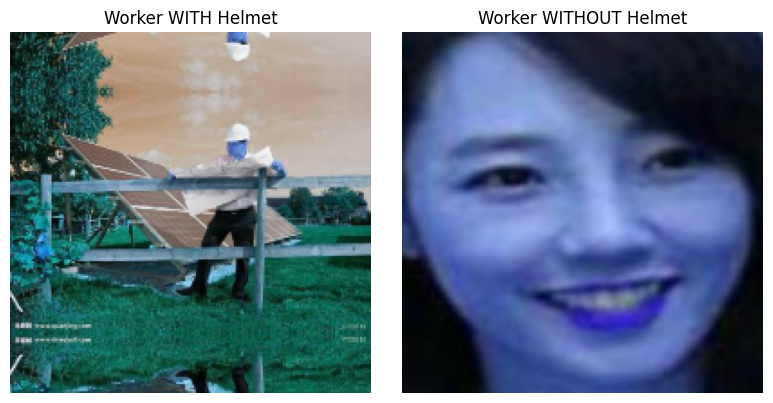

In [9]:
# separates data into classes
helmet_indices = np.where(labels == 1)[0]
no_helmet_indices = np.where(labels == 0)[0]  

# Select one image from each class
helmet_img = images[np.random.choice(helmet_indices)]
no_helmet_img = images[np.random.choice(no_helmet_indices)]

# Plot the images
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Display "With Helmet" image
axes[0].imshow(helmet_img)
axes[0].set_title("Worker WITH Helmet")
axes[0].axis('off')

# Display "Without Helmet" image
axes[1].imshow(no_helmet_img)
axes[1].set_title("Worker WITHOUT Helmet")
axes[1].axis('off')

# Show the plots
plt.tight_layout()
plt.show()

## Checking for class imbalance


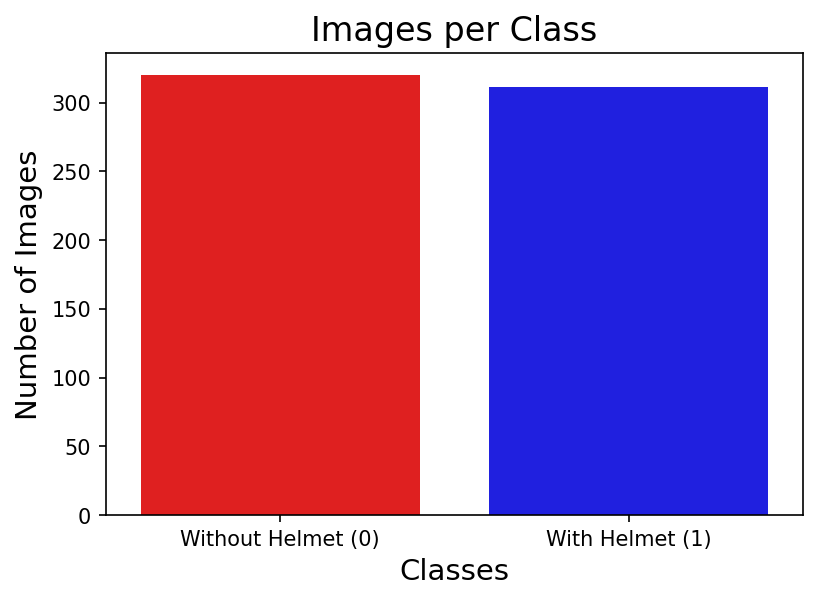

In [10]:
plt.figure(figsize=(6, 4), dpi=150)
sns.countplot(x=labels.iloc[:, 0], palette=['red', 'blue'])
plt.xlabel("Classes", fontsize=14)
plt.ylabel("Number of Images", fontsize=14)
plt.title("Images per Class", fontsize=16)
plt.xticks(ticks=[0, 1], labels=["Without Helmet (0)", "With Helmet (1)"]) ;

This is a a balanced dataset. While the number of images in each class is not exact, they are close. Each class has just over 300 images. 

# **Data Preprocessing**

## Converting images to grayscale

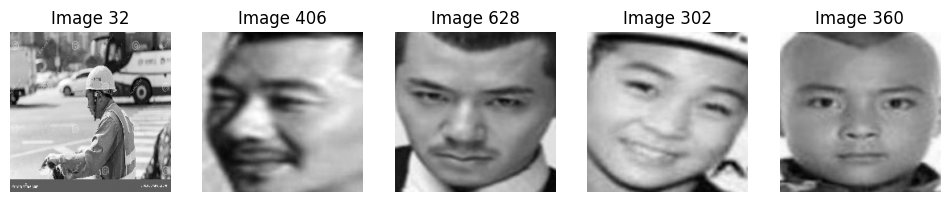

In [11]:
# Convert all images to grayscale
images_gray = [cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in images]

# Display a random sample of grayscale images
num_samples = 5  # number of images to show
sample_indices = random.sample(range(len(images_gray)), num_samples)

plt.figure(figsize=(12, 6))
for i, idx in enumerate(sample_indices):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(images_gray[idx], cmap='gray')  # use gray colormap
    plt.axis("off")
    plt.title(f"Image {idx}")
plt.show()


In [12]:
# Checking to confirm that the images are now gray scale. Only height and width, no channels.
print(images[0].shape)        # original image
print(images_gray[0].shape)   # converted grayscale image

(200, 200, 3)
(200, 200)


## Split Dataset

In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(np.array(images_gray),labels , test_size=0.25, random_state=42,stratify=labels)

In [14]:
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp , test_size=0.5, random_state=42,stratify=y_temp)

In [15]:
images.shape

(631, 200, 200, 3)

In [16]:
X_train.shape

(473, 200, 200)

In [17]:
X_val.shape

(79, 200, 200)

In [18]:
X_test.shape

(79, 200, 200)

Checking the shape of the various data elements trying to decide on the appropriate split given the small size of the data set. This may be something that will need to be revisited depending on model performance. 

### Data Normalization

In [19]:
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

# **Model Building**

## Model Evaluation Criterion

## Utility Functions

In [20]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [21]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

## Model 1: Simple Convolutional Neural Network (CNN)

In [22]:
# Initializing Model
model_1 = Sequential()

# Feature extraction = Convolutional and pooling layers
model_1.add(Conv2D(32, (3, 3), activation='relu', padding="same", input_shape=(200,200,1))) 
model_1.add(MaxPooling2D((4, 4), padding='same'))
model_1.add(Conv2D(16, (3, 3), activation='relu', padding="same")) 
model_1.add(MaxPooling2D((4,4), padding='same')) 
model_1.add(Conv2D(8, (3,3), activation='relu', padding="same")) 
model_1.add(MaxPooling2D((4,4), padding='same')) 

# Flatten and Dense layers
model_1.add(Flatten())
model_1.add(Dense(8, activation='relu'))
model_1.add(Dense(4, activation='relu'))
model_1.add(Dense(1, activation='sigmoid'))  #Using the Sigmoid activation function sine this is binary classification 

# Compile the Model with Adam Optimizer
model_1.compile(optimizer='Adam', loss='binary_crossentropy', metrics=["accuracy", "Precision"]) 

# Summary of the model parameters
model_1.summary()

I0000 00:00:1759454966.861981    2271 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         1,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,177 (28.04 KB)

 Trainable params: 7,177 (28.04 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# To determine input size
images_gray[0].shape

(200, 200)

In [24]:
history_1 = model_1.fit(
            X_train_normalized, y_train,
            epochs=15, 
            validation_data=(X_val_normalized,y_val),
            shuffle=True,
            batch_size=20, 
            verbose=2
)

Epoch 1/15


2025-10-02 20:29:29.739780: I external/local_xla/xla/service/service.cc:163] XLA service 0x71cd14015640 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-02 20:29:29.739888: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-10-02 20:29:29.835640: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-02 20:29:30.170430: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91301
I0000 00:00:1759454974.853820    2641 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


24/24 - 10s - 430ms/step - Precision: 0.0000e+00 - accuracy: 0.5074 - loss: 0.6888 - val_Precision: 0.0000e+00 - val_accuracy: 0.5063 - val_loss: 0.6739
Epoch 2/15
24/24 - 0s - 15ms/step - Precision: 1.0000 - accuracy: 0.6406 - loss: 0.6491 - val_Precision: 1.0000 - val_accuracy: 0.6456 - val_loss: 0.5987
Epoch 3/15
24/24 - 0s - 15ms/step - Precision: 1.0000 - accuracy: 0.8118 - loss: 0.5339 - val_Precision: 1.0000 - val_accuracy: 0.9494 - val_loss: 0.4443
Epoch 4/15
24/24 - 0s - 14ms/step - Precision: 1.0000 - accuracy: 0.9260 - loss: 0.4248 - val_Precision: 1.0000 - val_accuracy: 0.9873 - val_loss: 0.4223
Epoch 5/15
24/24 - 0s - 15ms/step - Precision: 1.0000 - accuracy: 0.9662 - loss: 0.3819 - val_Precision: 1.0000 - val_accuracy: 0.9873 - val_loss: 0.3629
Epoch 6/15
24/24 - 0s - 15ms/step - Precision: 1.0000 - accuracy: 0.9831 - loss: 0.3429 - val_Precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.3425
Epoch 7/15
24/24 - 0s - 15ms/step - Precision: 1.0000 - accuracy: 0.9831 - lo

### Vizualizing the predictions

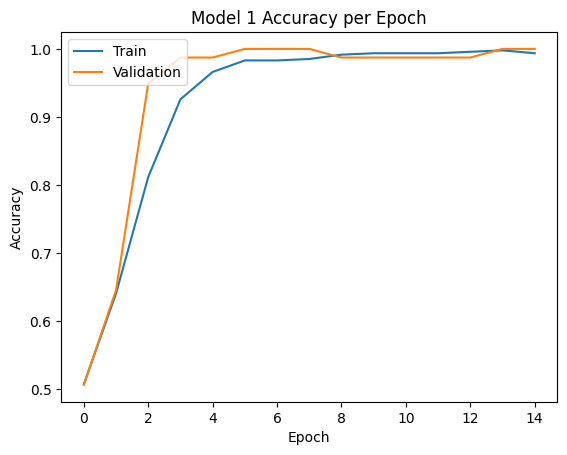

In [25]:
plt.plot(history_1.history['accuracy']) 
plt.plot(history_1.history['val_accuracy']) 
plt.title('Model 1 Accuracy per Epoch') 
plt.ylabel('Accuracy') 
plt.xlabel('Epoch') 
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [26]:
model_1_train_perf = model_performance_classification(model_1, X_train_normalized,y_train)

print("Train performance metrics")
print(model_1_train_perf)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.995772  0.995772   0.995808  0.995772


In [27]:
model_1_valid_perf = model_performance_classification(model_1, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_1_valid_perf)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 334ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


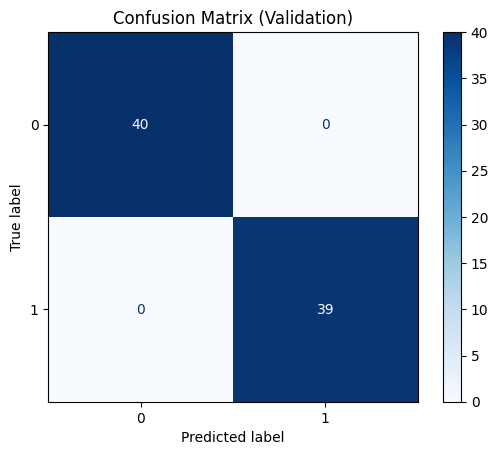

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        40
           1     1.0000    1.0000    1.0000        39

    accuracy                         1.0000        79
   macro avg     1.0000    1.0000    1.0000        79
weighted avg     1.0000    1.0000    1.0000        79

ROC AUC  : 1.0


In [28]:

y_prob = model_1.predict(X_val_normalized, verbose=0).ravel()   # shape (n,)
y_true = np.asarray(y_val).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Create Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Validation)")
plt.show()

# 5) Metrics
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
print("F1-score :", f1_score(y_true, y_pred, zero_division=0))
print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))

# Optional: ROC AUC (works with probabilities)
try:
    print("ROC AUC  :", roc_auc_score(y_true, y_prob))
except ValueError:
    pass


## Model 2: (VGG-16 (Base))

In [29]:
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(200, 200, 3))
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Freeze VGG-16 layers so they don't pick up training
for layer in vgg_model.layers:
    layer.trainable = False

### Create Model 2

In [31]:
model_2 = Sequential()
model_2.add(vgg_model)
model_2.add(Flatten())
model_2.add(Dense(1, activation='sigmoid'))
model_2.compile(optimizer='Adam', loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy", "Precision"])
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │        18,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,121 (56.20 MB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [32]:
train_datagen = ImageDataGenerator(preprocessing_function=lambda x: preprocess_input(x * 255.0))

In [33]:
# Fitting the model
batch_size = 20

# Make 3-channel inputs (N, H, W, 3)
X_train_3ch = np.repeat(X_train_normalized[..., None].astype('float32'), 3, axis=-1)
X_val_3ch   = np.repeat(X_val_normalized[..., None].astype('float32'),   3, axis=-1)

history_2 = model_2.fit(
    train_datagen.flow(X_train_3ch, y_train, batch_size=batch_size, seed=42, shuffle=True),
    epochs=25,
    steps_per_epoch=math.ceil(X_train_3ch.shape[0] / batch_size),  # or omit; Keras can infer
    validation_data=(X_val_3ch, y_val),
    verbose=2
)


Epoch 1/25


2025-10-02 20:29:50.810101: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.66GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-10-02 20:30:04.586239: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.04GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-10-02 20:30:05.887044: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng33{k2=2,k6=0,k13=1,k14=0,k22=1} for conv (f32[32,128,100,100]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,100,100]{3,2,1,0}, f32[128,64,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasAct

24/24 - 30s - 1s/step - Precision: 0.9496 - accuracy: 0.9598 - loss: 0.3302 - val_Precision: 0.6190 - val_accuracy: 0.6962 - val_loss: 0.4468
Epoch 2/25
24/24 - 2s - 74ms/step - Precision: 1.0000 - accuracy: 1.0000 - loss: 4.0093e-10 - val_Precision: 0.6393 - val_accuracy: 0.7215 - val_loss: 0.4025
Epoch 3/25
24/24 - 2s - 76ms/step - Precision: 1.0000 - accuracy: 1.0000 - loss: 3.6115e-10 - val_Precision: 0.6393 - val_accuracy: 0.7215 - val_loss: 0.3982
Epoch 4/25
24/24 - 2s - 78ms/step - Precision: 1.0000 - accuracy: 1.0000 - loss: 3.4808e-10 - val_Precision: 0.6393 - val_accuracy: 0.7215 - val_loss: 0.3978
Epoch 5/25
24/24 - 2s - 78ms/step - Precision: 1.0000 - accuracy: 1.0000 - loss: 3.4662e-10 - val_Precision: 0.6393 - val_accuracy: 0.7215 - val_loss: 0.3978
Epoch 6/25
24/24 - 2s - 79ms/step - Precision: 1.0000 - accuracy: 1.0000 - loss: 3.4490e-10 - val_Precision: 0.6393 - val_accuracy: 0.7215 - val_loss: 0.3978
Epoch 7/25
24/24 - 2s - 78ms/step - Precision: 1.0000 - accuracy: 1.

### Visualizing the prediction:

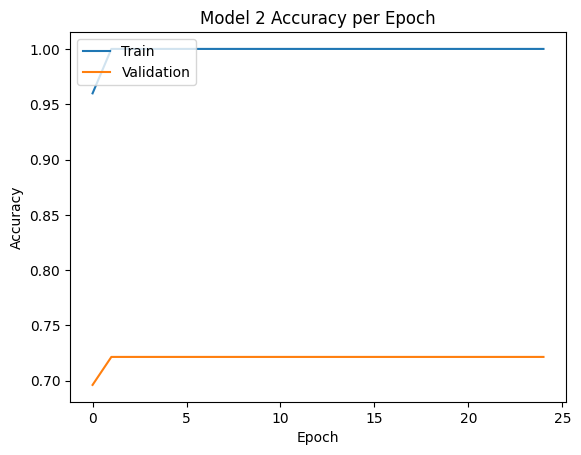

In [34]:
plt.plot(history_2.history['accuracy']) #Complete the code to plot the train metrics
plt.plot(history_2.history['val_accuracy']) #Complete the code to plot the validation data metrics
plt.title('Model 2 Accuracy per Epoch') #Complete the code to define the title for the plot
plt.ylabel('Accuracy') #Complete the code to define the label for the y-axis
plt.xlabel('Epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [35]:
model_2_train_perf = model_performance_classification(model_2, X_train_3ch,y_train)

print("Train performance metrics")
print(model_2_train_perf)

14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

2025-10-02 20:31:07.819363: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.82GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-10-02 20:31:12.311423: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng11{k2=3,k3=0} for conv (f32[25,256,50,50]{3,2,1,0}, u8[0]{0}) custom-call(f32[25,256,50,50]{3,2,1,0}, f32[256,256,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-10-02 20:31:12.489863: E external/local_xla/xla

15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 743ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.712474  0.712474   0.818445  0.688115


In [36]:
model_2_valid_perf = model_performance_classification(model_2, X_val_3ch,y_val)

print("Validation performance metrics")
print(model_2_valid_perf)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 274ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.721519  0.721519   0.821955  0.699337


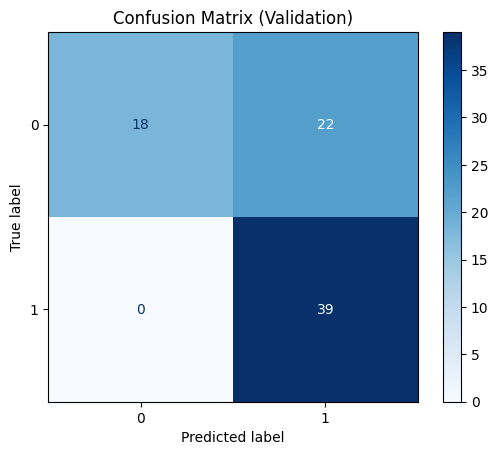

Accuracy : 0.7215189873417721
Precision: 0.639344262295082
Recall   : 1.0
F1-score : 0.78

Classification Report:
               precision    recall  f1-score   support

           0     1.0000    0.4500    0.6207        40
           1     0.6393    1.0000    0.7800        39

    accuracy                         0.7215        79
   macro avg     0.8197    0.7250    0.7003        79
weighted avg     0.8220    0.7215    0.6993        79

ROC AUC  : 0.9993589743589744


In [37]:

y_prob = model_2.predict(X_val_3ch, verbose=0).ravel()   # shape (n,)
y_true = np.asarray(y_val).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Create Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Validation)")
plt.show()

# 5) Metrics
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
print("F1-score :", f1_score(y_true, y_pred, zero_division=0))
print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))

# Optional: ROC AUC (works with probabilities)
try:
    print("ROC AUC  :", roc_auc_score(y_true, y_prob))
except ValueError:
    pass


## Model 3: (VGG-16 (Base + FFNN))

### Create Model 3

In [38]:
model_3 = Sequential()

# Feature Extraction 
model_3.add(vgg_model)
model_3.add(Flatten())

# Prediction
model_3.add(Dense(32,activation='relu')) 
model_3.add(Dropout(rate=0.5))
model_3.add(Dense(16,activation='relu')) 
model_3.add(Dropout(rate=0.5))

# Output Layer
model_3.add(Dense(1, activation='sigmoid')) 

opt = Adam(learning_rate=0.5) 

model_3.compile(optimizer='Adam',loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy", "Precision"])
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │       589,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,305,089 (58.38 MB)

 Trainable params: 590,401 (2.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [39]:
batch_size = 20

# Make 3-channel inputs (N, H, W, 3)
X_train_3ch = np.repeat(X_train_normalized[..., None].astype('float32'), 3, axis=-1)
X_val_3ch   = np.repeat(X_val_normalized[..., None].astype('float32'),   3, axis=-1)

history_3 = model_3.fit(
    train_datagen.flow(X_train_3ch, y_train, batch_size=batch_size, seed=42, shuffle=True),
    epochs=25,
    steps_per_epoch=math.ceil(X_train_3ch.shape[0] / batch_size),  # or omit; Keras can infer
    validation_data=(X_val_3ch, y_val),
    verbose=2
)


Epoch 1/25
24/24 - 7s - 309ms/step - Precision: 0.8296 - accuracy: 0.8182 - loss: 1.9676 - val_Precision: 1.0000 - val_accuracy: 0.9494 - val_loss: 0.3206
Epoch 2/25
24/24 - 2s - 77ms/step - Precision: 0.9227 - accuracy: 0.9006 - loss: 1.2326 - val_Precision: 0.5493 - val_accuracy: 0.5949 - val_loss: 0.5215
Epoch 3/25
24/24 - 2s - 77ms/step - Precision: 0.9649 - accuracy: 0.9556 - loss: 0.4131 - val_Precision: 0.6610 - val_accuracy: 0.7468 - val_loss: 0.3726
Epoch 4/25
24/24 - 2s - 78ms/step - Precision: 0.9686 - accuracy: 0.9493 - loss: 0.3950 - val_Precision: 0.6290 - val_accuracy: 0.7089 - val_loss: 0.3766
Epoch 5/25
24/24 - 2s - 76ms/step - Precision: 0.9522 - accuracy: 0.9471 - loss: 0.4359 - val_Precision: 0.7091 - val_accuracy: 0.7975 - val_loss: 0.3694
Epoch 6/25
24/24 - 2s - 77ms/step - Precision: 0.9333 - accuracy: 0.9471 - loss: 0.4063 - val_Precision: 0.5909 - val_accuracy: 0.6582 - val_loss: 0.5339
Epoch 7/25
24/24 - 2s - 77ms/step - Precision: 0.9231 - accuracy: 0.9260 - 

#### Visualizing the predictions

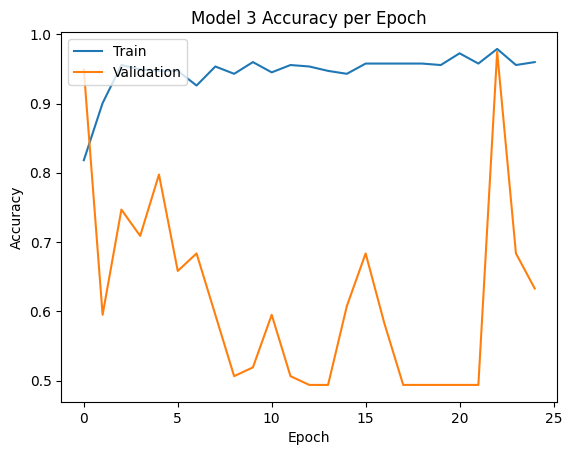

In [40]:
plt.plot(history_3.history['accuracy'])
plt.plot(history_3.history['val_accuracy'])
plt.title('Model 3 Accuracy per Epoch')
plt.ylabel('Accuracy')
plt.xlabel('Epoch') 
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [41]:
model_3_train_perf = model_performance_classification(model_3, X_train_3ch,y_train)

print("Train performance metrics")
print(model_3_train_perf)

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.598309  0.598309   0.778737  0.524892


In [42]:
model_3_valid_perf = model_performance_classification(model_3, X_val_3ch,y_val)

print("Validation performance metrics")
print(model_3_valid_perf)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.632911  0.632911   0.789464  0.578289


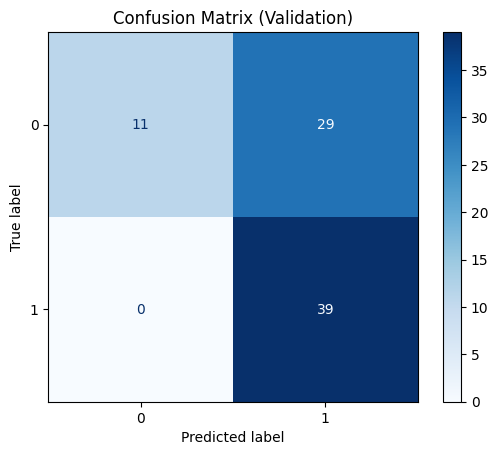

Accuracy : 0.6329113924050633
Precision: 0.5735294117647058
Recall   : 1.0
F1-score : 0.7289719626168224

Classification Report:
               precision    recall  f1-score   support

           0     1.0000    0.2750    0.4314        40
           1     0.5735    1.0000    0.7290        39

    accuracy                         0.6329        79
   macro avg     0.7868    0.6375    0.5802        79
weighted avg     0.7895    0.6329    0.5783        79

ROC AUC  : 1.0


In [43]:

y_prob = model_3.predict(X_val_3ch, verbose=0).ravel()   # shape (n,)
y_true = np.asarray(y_val).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Create Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Validation)")
plt.show()

# 5) Metrics
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
print("F1-score :", f1_score(y_true, y_pred, zero_division=0))
print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))

# Optional: ROC AUC (works with probabilities)
try:
    print("ROC AUC  :", roc_auc_score(y_true, y_prob))
except ValueError:
    pass


In [44]:
model_3_train_perf = model_performance_classification(model_3, X_train_3ch,y_train)

print("Train performance metrics")
print(model_3_train_perf)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.598309  0.598309   0.778737  0.524892


## Model 4: (VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [45]:
model_4 = Sequential()

# Feature Extraction 
model_4.add(vgg_model)
model_4.add(Flatten())

# Prediction
model_4.add(Dense(32,activation='relu')) 
model_4.add(Dropout(rate=0.5))
model_4.add(Dense(16,activation='relu')) 
model_4.add(Dropout(rate=0.5))

# Output Layer
model_4.add(Dense(1, activation='sigmoid')) 

opt = Adam(learning_rate=0.5) 

model_4.compile(optimizer='Adam',loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy", "Precision"])
model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │       589,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,305,089 (58.38 MB)

 Trainable params: 590,401 (2.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [46]:
train_datagen = ImageDataGenerator(
                              rotation_range=0.5, 
                              fill_mode='nearest',width_shift_range=0.5,height_shift_range=0.5,shear_range=0.5,zoom_range=0.5
                              )

In [47]:
batch_size = 20

# Make 3-channel inputs (N, H, W, 3)
X_train_3ch = np.repeat(X_train_normalized[..., None].astype('float32'), 3, axis=-1)
X_val_3ch   = np.repeat(X_val_normalized[..., None].astype('float32'),   3, axis=-1)

history_4 = model_4.fit(
    train_datagen.flow(X_train_3ch, y_train, batch_size=batch_size, seed=42, shuffle=True),
    epochs=25,
    steps_per_epoch=math.ceil(X_train_3ch.shape[0] / batch_size),  # or omit; Keras can infer
    validation_data=(X_val_3ch, y_val),
    verbose=2
)

Epoch 1/25
24/24 - 9s - 394ms/step - Precision: 0.5513 - accuracy: 0.5581 - loss: 0.7821 - val_Precision: 0.9750 - val_accuracy: 0.9873 - val_loss: 0.5441
Epoch 2/25
24/24 - 2s - 96ms/step - Precision: 0.7416 - accuracy: 0.6892 - loss: 0.5807 - val_Precision: 0.9750 - val_accuracy: 0.9873 - val_loss: 0.3404
Epoch 3/25
24/24 - 2s - 90ms/step - Precision: 0.7936 - accuracy: 0.7780 - loss: 0.5242 - val_Precision: 0.9750 - val_accuracy: 0.9873 - val_loss: 0.2623
Epoch 4/25
24/24 - 2s - 88ms/step - Precision: 0.8687 - accuracy: 0.8161 - loss: 0.4389 - val_Precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0985
Epoch 5/25
24/24 - 2s - 94ms/step - Precision: 0.9095 - accuracy: 0.8710 - loss: 0.3418 - val_Precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0812
Epoch 6/25
24/24 - 2s - 94ms/step - Precision: 0.9327 - accuracy: 0.8879 - loss: 0.3161 - val_Precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0478
Epoch 7/25
24/24 - 2s - 94ms/step - Precision: 0.9596 - accuracy: 0.8922 - 

#### Visualizing the predictions

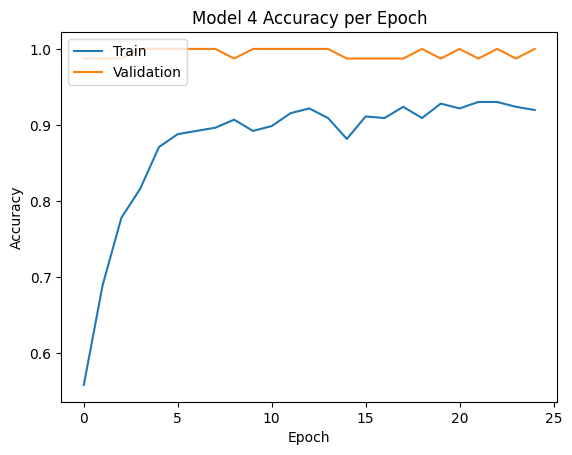

In [48]:
plt.plot(history_4.history['accuracy'])
plt.plot(history_4.history['val_accuracy'])
plt.title('Model 4 Accuracy per Epoch')
plt.ylabel('Accuracy')
plt.xlabel('Epoch') 
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [49]:
model_4_train_perf = model_performance_classification(model_4, X_train_3ch,y_train)

print("Train performance metrics")
print(model_4_train_perf)

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


In [50]:
model_4_valid_perf = model_performance_classification(model_4, X_val_3ch,y_val)

print("Validation performance metrics")
print(model_4_valid_perf)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 305ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


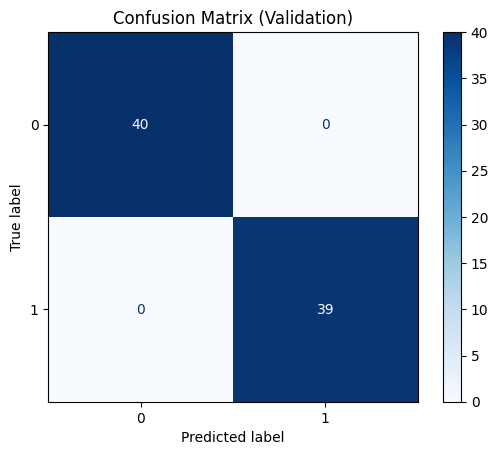

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        40
           1     1.0000    1.0000    1.0000        39

    accuracy                         1.0000        79
   macro avg     1.0000    1.0000    1.0000        79
weighted avg     1.0000    1.0000    1.0000        79

ROC AUC  : 1.0


In [51]:

y_prob = model_4.predict(X_val_3ch, verbose=0).ravel()   # shape (n,)
y_true = np.asarray(y_val).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Create Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Validation)")
plt.show()

# 5) Metrics
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
print("F1-score :", f1_score(y_true, y_pred, zero_division=0))
print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))

# Optional: ROC AUC (works with probabilities)
try:
    print("ROC AUC  :", roc_auc_score(y_true, y_prob))
except ValueError:
    pass


# **Model Performance Comparison and Final Model Selection**

In [52]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Simple Convolutional Neural Network (CNN)","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [53]:
models_valid_comp_df = pd.concat(
    [
        model_1_valid_perf.T,
        model_2_valid_perf.T,
        model_3_valid_perf.T,
        model_4_valid_perf.T

    ],
    axis=1,
)
models_valid_comp_df.columns = [
 "Simple Convolutional Neural Network (CNN)","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [54]:
models_train_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.995772,0.712474,0.598309,1.0
Recall,0.995772,0.712474,0.598309,1.0
Precision,0.995808,0.818445,0.778737,1.0
F1 Score,0.995772,0.688115,0.524892,1.0


In [55]:
models_valid_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,1.0,0.721519,0.632911,1.0
Recall,1.0,0.721519,0.632911,1.0
Precision,1.0,0.821955,0.789464,1.0
F1 Score,1.0,0.699337,0.578289,1.0


In [56]:
models_train_comp_df - models_valid_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,-0.004228,-0.009045,-0.034603,0.0
Recall,-0.004228,-0.009045,-0.034603,0.0
Precision,-0.004192,-0.003509,-0.010726,0.0
F1 Score,-0.004228,-0.011222,-0.053397,0.0


## Test Performance

# **Actionable Insights & Recommendations**

-
-

<font size=5 color='blue'>Power Ahead!</font>
___

In [57]:
end_time = time.time()
total_time = (end_time - start_time)/60
print(round(total_time,3))

4.005
